In [1]:
# ============================================
# Startup Cell: Mount Drive + Prepare Data
# ============================================

from google.colab import drive
drive.mount("/content/drive")

import os
import shutil

BASE_DRIVE_DIR = "/content/drive/MyDrive/DIP_Project"
CONTENT_DIR = "/content"
IMG_DIR = "/content/images"

INPUT_FILES = [
    "train_metadata.csv",
    "validation_metadata.csv",
    "test_metadata.csv",
]

ZIP_FILENAME = "images.zip"
ZIP_PATH = os.path.join(BASE_DRIVE_DIR, ZIP_FILENAME)

# --------------------------------------------
# Copy metadata CSVs to /content
# --------------------------------------------
print("Copying metadata CSV files...")

for filename in INPUT_FILES:
    src = os.path.join(BASE_DRIVE_DIR, filename)
    dst = os.path.join(CONTENT_DIR, filename)

    if not os.path.exists(src):
        raise FileNotFoundError(f"Missing source file: {src}")

    shutil.copy(src, dst)
    print(f"Copied: {filename}")

print("\nMetadata CSVs copied.")

# --------------------------------------------
# Unzip images if needed
# --------------------------------------------
if not os.path.isdir(IMG_DIR) or len(os.listdir(IMG_DIR)) == 0:
    print("\nPreparing image directory and extracting images.zip...")

    if not os.path.exists(ZIP_PATH):
        raise FileNotFoundError(f"Missing image archive: {ZIP_PATH}")

    os.makedirs(IMG_DIR, exist_ok=True)

    local_zip_path = os.path.join(CONTENT_DIR, ZIP_FILENAME)
    shutil.copy(ZIP_PATH, local_zip_path)

    !unzip -q "{local_zip_path}" -d /content/

    # Fix structure if images extracted directly into /content
    root_image_files = [
        f for f in os.listdir(CONTENT_DIR)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    if root_image_files:
        print("Fixing structure: moving extracted images into /content/images/")
        for fname in root_image_files:
            shutil.move(os.path.join(CONTENT_DIR, fname), os.path.join(IMG_DIR, fname))
else:
    print("\nImages already present.")

# --------------------------------------------
# Verification
# --------------------------------------------
print("\nVerification:")
print("Image count:", len(os.listdir(IMG_DIR)))
for filename in INPUT_FILES:
    print(f"{filename}: ", os.path.exists(os.path.join(CONTENT_DIR, filename)))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying metadata CSV files...
Copied: train_metadata.csv
Copied: validation_metadata.csv
Copied: test_metadata.csv

Metadata CSVs copied.

Images already present.

Verification:
Image count: 12000
train_metadata.csv:  True
validation_metadata.csv:  True
test_metadata.csv:  True


In [2]:
# ============================================
# Cell 0: Notebook Overview
# ============================================
# Purpose:
#   This notebook explores and validations frequency-domain feature
#   extraction using a selected split of the preprocessed image
#   dataset.
#
# Inputs:
#   The notebook expects:
#     - split-specific metadata CSV file:
#         /content/train_metadata.csv
#         /content/validation_metadata.csv
#         /content/test_metadata.csv
#     - shared preprocessed image directory containing all 12000 images:
#         /content/images/
#
# Assumptions:
#   - The shared image directory contains all 12000 preprocessed images.
#   - The selected metadata CSV identifies which images belong to the
#     chosen dataset split.
#   - All images have already been preprocessed.
#   - All images are already grayscale.
#   - All images have already been resized to 256 x 256.
#   - This notebook does NOT perform resizing or grayscale conversion.
#   - This notebook focuses only on frequency-domain feature extraction.
#   - Class labels are taken from metadata, not inferred from filenames.
#   - Expected split sizes are:
#       - train: 8400 images
#       - validation: 1800 images
#       - test: 1800 images
#
# What the notebook does:
#   Cell 1:
#     Import required libraries for image loading, numerical processing,
#     Fourier analysis, feature extraction, and visualization.
#
#   Cell 2:
#     Define the selected split, input paths, output path, and select
#     one sample image from the chosen metadata for exploratory analysis.
#
#   Cell 3:
#     Verify required inputs exist before processing:
#       - confirm the selected metadata CSV exists
#       - confirm /content/images/ directory exists
#       - confirm image files are present
#       - confirm metadata has expected columns and expected row count
#         for the selected split
#       - confirm sample image filenames match actual files
#
#   Cell 4:
#     Load the selected preprocessed image and verify its properties,
#     including:
#       - shape
#       - datatype
#       - intensity range
#
#   Cell 5:
#     Define helper functions for:
#       - 2D Fourier transform computation
#       - centered magnitude and power spectrum computation
#       - radial profile computation
#       - frequency-band energy ratio computation
#       - frequency-domain feature extraction
#
#   Cell 6:
#     Compute intermediate frequency-domain representations for the
#     sample image, including:
#       - Fourier transform
#       - centered magnitude spectrum
#       - log-magnitude spectrum
#       - power spectrum
#       - radial energy profile
#
#   Cell 7:
#     Display intermediate visual results for the sample image:
#       - input image
#       - centered log-magnitude spectrum
#       - power spectrum visualization
#       - radial profile plot
#
#   Cell 8:
#     Plot histograms or profiles related to:
#       - spectrum magnitude values
#       - radial energy values
#
#   Cell 9:
#     Compute and print these 9 frequency-domain features for the sample
#     image:
#       - Low Frequency Energy Ratio
#       - Mid Frequency Energy Ratio
#       - High Frequency Energy Ratio
#       - Radial Mean
#       - Radial Std
#       - Radial Entropy
#       - Spectral Centroid
#       - Spectral Bandwidth
#       - Log Spectrum Std
#
#   Cell 10:
#     Repeat the same analysis on a small set of additional images from
#     the selected split to compare real and AI-generated examples.
#
#   Cell 11:
#     Apply frequency-domain feature extraction to all images identified
#     by the selected metadata CSV and save the results to a split-
#     specific output file:
#       /content/train_frequency_features.csv
#       /content/validation_frequency_features.csv
#       /content/test_frequency_features.csv
#
# Outputs:
#   Primary output:
#     - visual validation of frequency-domain feature extraction behavior
#     - printed frequency-domain feature values for selected images
#
#   Optional CSV output:
#     - /content/train_frequency_features.csv
#     - /content/validation_frequency_features.csv
#     - /content/test_frequency_features.csv
#
# Notes:
#   - This is an exploratory notebook intended to verify correctness
#     before scaling to full dataset feature extraction.
#   - Only images listed in the selected metadata CSV are used for
#     feature extraction, even though /content/images/ contains all
#     12000 preprocessed images.
#   - Only frequency-domain features are extracted in this notebook.
#   - Later work can combine gradient, spatial, and frequency-domain
#     features into a single dataset for classifier training and
#     evaluation.
#   - The same notebook structure and functionality are preserved while
#     allowing selection of the train, validation, or test split.
# ============================================

print("Notebook overview loaded.")



Notebook overview loaded.


In [3]:
# ============================================
# Cell 1: Imports
# ============================================

import os

import numpy as np
import pandas as pd

import cv2
from PIL import Image

import matplotlib.pyplot as plt

from scipy.stats import entropy

print("Libraries imported successfully.")



Libraries imported successfully.


In [4]:
# ============================================
# Cell 2: Define Input Paths and Sample Image
# ============================================

import os

# -------------------------------------------------
# Select dataset split
# -------------------------------------------------
SPLIT_NAME = "train"   # options: "train", "validation", "test"

# -------------------------------------------------
# Define paths
# -------------------------------------------------
METADATA_CSV = f"/content/{SPLIT_NAME}_metadata.csv"
IMG_DIR = "/content/images"

# Output CSV (for full dataset extraction)
OUTPUT_CSV = f"/content/{SPLIT_NAME}_frequency_features.csv"

# -------------------------------------------------
# Expected row counts (for validation in Cell 3)
# -------------------------------------------------
EXPECTED_ROWS = {
    "train": 8400,
    "validation": 1800,
    "test": 1800
}

# -------------------------------------------------
# Sample image (set in Cell 3 after loading metadata)
# -------------------------------------------------
SAMPLE_FILENAME = None
SAMPLE_IMAGE_PATH = None

# -------------------------------------------------
# Display configuration
# -------------------------------------------------
print("SPLIT_NAME      =", SPLIT_NAME)
print("METADATA_CSV    =", METADATA_CSV)
print("IMG_DIR         =", IMG_DIR)
print("OUTPUT_CSV      =", OUTPUT_CSV)
print("EXPECTED_ROWS   =", EXPECTED_ROWS[SPLIT_NAME])
print("SAMPLE_IMAGE    =", SAMPLE_IMAGE_PATH)



SPLIT_NAME      = validation
METADATA_CSV    = /content/validation_metadata.csv
IMG_DIR         = /content/images
OUTPUT_CSV      = /content/validation_frequency_features.csv
EXPECTED_ROWS   = 1800
SAMPLE_IMAGE    = None


In [5]:
# ============================================
# Cell 3: Input Validation
# ============================================

# --- Check metadata CSV ---
assert os.path.exists(METADATA_CSV), f"Missing file: {METADATA_CSV}"
print(f"PASS: Found metadata CSV -> {METADATA_CSV}")

# --- Check shared image directory ---
assert os.path.isdir(IMG_DIR), f"Missing directory: {IMG_DIR}"
print(f"PASS: Found image directory -> {IMG_DIR}")

# --- Check image files exist ---
image_files = os.listdir(IMG_DIR)
assert len(image_files) > 0, "No images found in shared image directory"
print(f"PASS: Found {len(image_files)} files in image directory")

# --- Load selected-split metadata ---
df = pd.read_csv(METADATA_CSV)
print(f"PASS: Loaded metadata CSV with shape {df.shape}")

# --- Check expected row count ---
assert df.shape[0] == EXPECTED_ROWS[SPLIT_NAME], (
    f"Expected {EXPECTED_ROWS[SPLIT_NAME]} rows for {SPLIT_NAME}, "
    f"found {df.shape[0]}"
)
print(f"PASS: Metadata contains expected {EXPECTED_ROWS[SPLIT_NAME]} {SPLIT_NAME} rows")

# --- Check required columns ---
required_cols = ["filename", "class_label", "source_dataset", "subset"]
for col in required_cols:
    assert col in df.columns, f"Missing required column: {col}"
print("PASS: Required columns present")

# --- Verify subset column matches SPLIT_NAME ---
unique_subsets = sorted(df["subset"].dropna().unique().tolist())
assert unique_subsets == [SPLIT_NAME], (
    f"Subset mismatch: expected ['{SPLIT_NAME}'], got {unique_subsets}"
)
print(f"PASS: Subset column matches SPLIT_NAME -> {SPLIT_NAME}")

# --- Select sample image (first row of metadata) ---
SAMPLE_FILENAME = df["filename"].iloc[0]
SAMPLE_IMAGE_PATH = os.path.join(IMG_DIR, SAMPLE_FILENAME)

assert os.path.exists(SAMPLE_IMAGE_PATH), f"Sample image not found: {SAMPLE_FILENAME}"
print(f"PASS: Sample image selected -> {SAMPLE_FILENAME}")

# --- Check sample of metadata filenames exist ---
missing_files = []
for fname in df["filename"].head(10):
    fpath = os.path.join(IMG_DIR, fname)
    if not os.path.exists(fpath):
        missing_files.append(fname)

assert len(missing_files) == 0, f"Missing image files: {missing_files}"
print(f"PASS: Sample {SPLIT_NAME} metadata image files exist")

print("\nAll input validation checks passed.")


PASS: Found metadata CSV -> /content/validation_metadata.csv
PASS: Found image directory -> /content/images
PASS: Found 12000 files in image directory
PASS: Loaded metadata CSV with shape (1800, 5)
PASS: Metadata contains expected 1800 validation rows
PASS: Required columns present
PASS: Subset column matches SPLIT_NAME -> validation
PASS: Sample image selected -> ai_sdxl_000063.png
PASS: Sample validation metadata image files exist

All input validation checks passed.


Inspecting sample image from validation split: ai_sdxl_000063.png
Shape: (256, 256)
Dtype: float32
Min: 0.16862745583057404
Max: 0.9176470637321472
Mean: 0.5600972771644592
Std: 0.13999633491039276


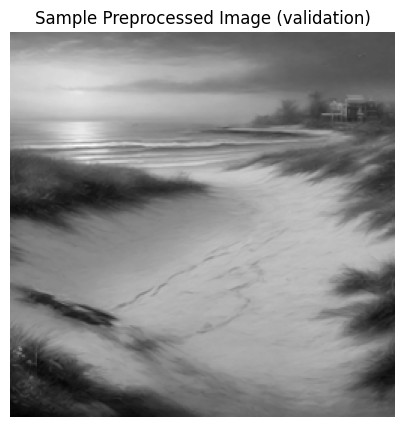

In [6]:
# ============================================
# Cell 4: Load and Inspect Sample Image
# ============================================

def load_preprocessed_image(image_path):
    img = Image.open(image_path)
    img = np.array(img)

    if img.ndim == 3 and img.shape[2] == 1:
        img = img[:, :, 0]
    elif img.ndim != 2:
        raise ValueError(f"Expected grayscale image, got shape {img.shape}")

    img = img.astype(np.float32)

    if img.max() > 1.0:
        img = img / 255.0

    return img


def inspect_image(img):
    print("Shape:", img.shape)
    print("Dtype:", img.dtype)
    print("Min:", float(img.min()))
    print("Max:", float(img.max()))
    print("Mean:", float(img.mean()))
    print("Std:", float(img.std()))


# Load sample image selected in Cell 3
img = load_preprocessed_image(SAMPLE_IMAGE_PATH)

print(f"Inspecting sample image from {SPLIT_NAME} split: {SAMPLE_FILENAME}")
inspect_image(img)

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title(f"Sample Preprocessed Image ({SPLIT_NAME})")
plt.axis("off")
plt.show()



In [7]:
# ============================================
# Cell 5: Frequency Feature Helper Functions
# ============================================

def compute_fft(img):
    F = np.fft.fft2(img)
    F_shift = np.fft.fftshift(F)
    return F_shift


def compute_magnitude_spectrum(F_shift):
    mag = np.abs(F_shift)
    log_mag = np.log1p(mag)
    power = mag ** 2
    return mag, log_mag, power


def radial_profile(power_spectrum):
    h, w = power_spectrum.shape
    cy, cx = h // 2, w // 2

    y, x = np.indices((h, w))
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    r = r.astype(np.int32)

    max_r = r.max()
    radial_mean = np.zeros(max_r + 1, dtype=np.float32)

    for i in range(max_r + 1):
        mask = (r == i)
        if np.any(mask):
            radial_mean[i] = power_spectrum[mask].mean()

    return radial_mean


def radial_entropy(radial_vals):
    hist, _ = np.histogram(radial_vals, bins=64)
    hist = hist.astype(np.float64)
    hist = hist / (hist.sum() + 1e-12)
    hist = np.clip(hist, 1e-12, None)
    return float(entropy(hist, base=2))


def frequency_band_ratios(power_spectrum):
    h, w = power_spectrum.shape
    cy, cx = h // 2, w // 2

    y, x = np.indices((h, w))
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)

    max_r = np.max(r)

    low_mask = r <= max_r * 0.2
    mid_mask = (r > max_r * 0.2) & (r <= max_r * 0.5)
    high_mask = r > max_r * 0.5

    total_energy = power_spectrum.sum() + 1e-12

    low_ratio = float(power_spectrum[low_mask].sum() / total_energy)
    mid_ratio = float(power_spectrum[mid_mask].sum() / total_energy)
    high_ratio = float(power_spectrum[high_mask].sum() / total_energy)

    return low_ratio, mid_ratio, high_ratio


def spectral_centroid(radial_vals):
    indices = np.arange(len(radial_vals))
    total = radial_vals.sum() + 1e-12
    centroid = float((indices * radial_vals).sum() / total)
    return centroid


def spectral_bandwidth(radial_vals, centroid):
    indices = np.arange(len(radial_vals))
    total = radial_vals.sum() + 1e-12
    variance = ((indices - centroid) ** 2 * radial_vals).sum() / total
    return float(np.sqrt(variance))


def extract_frequency_features(img):
    F_shift = compute_fft(img)
    mag, log_mag, power = compute_magnitude_spectrum(F_shift)

    radial_vals = radial_profile(power)

    low_ratio, mid_ratio, high_ratio = frequency_band_ratios(power)

    r_mean = float(np.mean(radial_vals))
    r_std = float(np.std(radial_vals))
    r_entropy = radial_entropy(radial_vals)

    centroid = spectral_centroid(radial_vals)
    bandwidth = spectral_bandwidth(radial_vals, centroid)

    log_std = float(np.std(log_mag))

    features = {
        "Low Frequency Energy Ratio": low_ratio,
        "Mid Frequency Energy Ratio": mid_ratio,
        "High Frequency Energy Ratio": high_ratio,
        "Radial Mean": r_mean,
        "Radial Std": r_std,
        "Radial Entropy": r_entropy,
        "Spectral Centroid": centroid,
        "Spectral Bandwidth": bandwidth,
        "Log Spectrum Std": log_std,
    }

    return features, log_mag, power, radial_vals

print("Frequency helper functions defined.")



Frequency helper functions defined.


In [8]:
# ============================================
# Cell 6: Compute Frequency Components
# ============================================

features_freq, log_mag, power, radial_vals = extract_frequency_features(img)

print(f"Frequency components computed successfully for {SPLIT_NAME} sample image.")
print("Log magnitude shape =", log_mag.shape)
print("Power spectrum shape =", power.shape)
print("Radial profile length =", len(radial_vals))



Frequency components computed successfully for validation sample image.
Log magnitude shape = (256, 256)
Power spectrum shape = (256, 256)
Radial profile length = 182


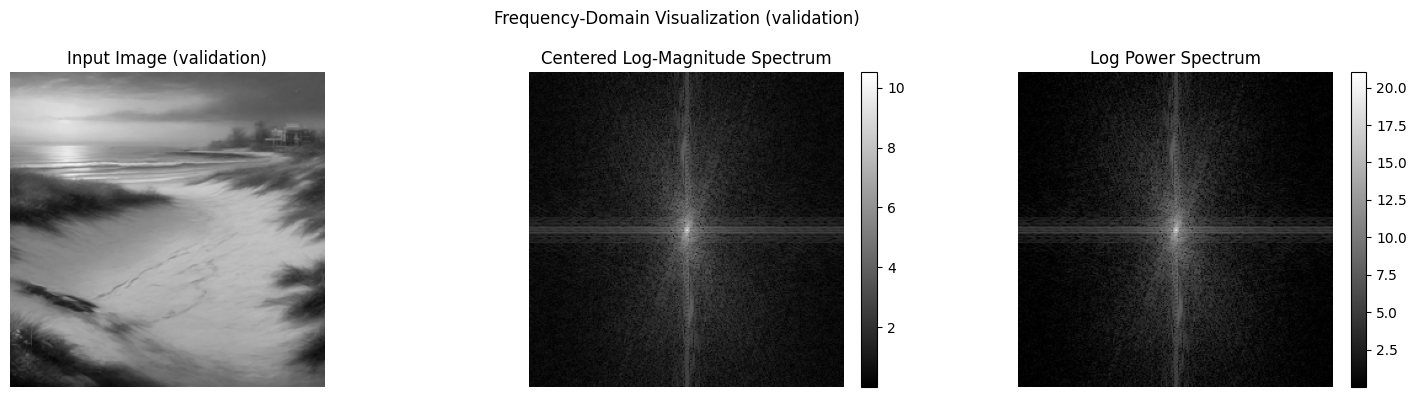

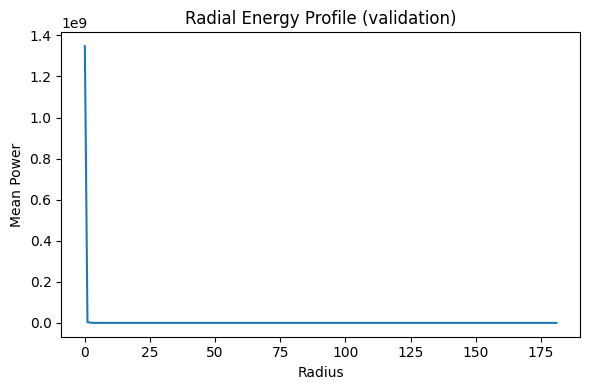

In [9]:
# ============================================
# Cell 7: Display Frequency Visualization Results
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(img, cmap="gray")
axes[0].set_title(f"Input Image ({SPLIT_NAME})")
axes[0].axis("off")

im1 = axes[1].imshow(log_mag, cmap="gray")
axes[1].set_title("Centered Log-Magnitude Spectrum")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(np.log1p(power), cmap="gray")
axes[2].set_title("Log Power Spectrum")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle(f"Frequency-Domain Visualization ({SPLIT_NAME})", fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(radial_vals)
plt.title(f"Radial Energy Profile ({SPLIT_NAME})")
plt.xlabel("Radius")
plt.ylabel("Mean Power")
plt.tight_layout()
plt.show()



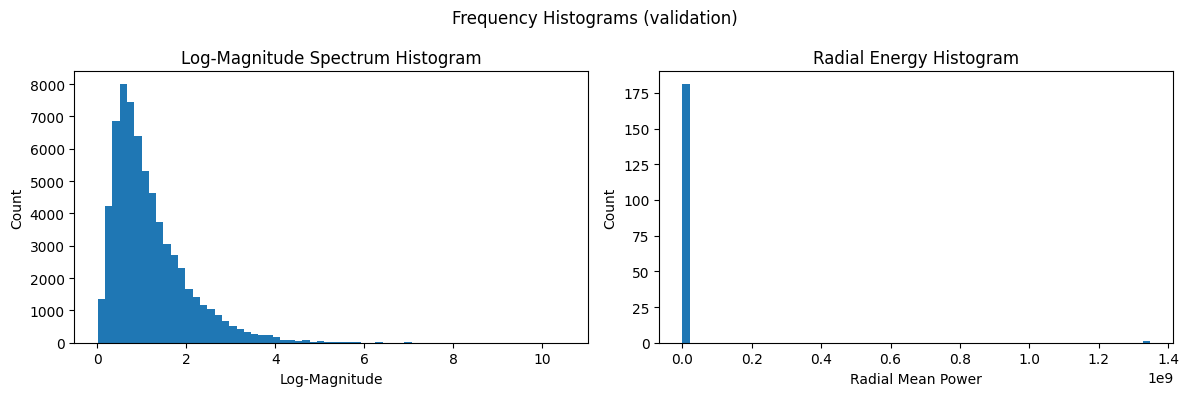

In [10]:
# ============================================
# Cell 8: Plot Frequency Histograms / Profiles
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(log_mag.ravel(), bins=64)
axes[0].set_title("Log-Magnitude Spectrum Histogram")
axes[0].set_xlabel("Log-Magnitude")
axes[0].set_ylabel("Count")

axes[1].hist(radial_vals, bins=64)
axes[1].set_title("Radial Energy Histogram")
axes[1].set_xlabel("Radial Mean Power")
axes[1].set_ylabel("Count")

plt.suptitle(f"Frequency Histograms ({SPLIT_NAME})", fontsize=12)
plt.tight_layout()
plt.show()



In [11]:
# ============================================
# Cell 9: Print Frequency Feature Values
# ============================================

print(f"Frequency Feature Values ({SPLIT_NAME})")
print(f"Sample Image: {SAMPLE_FILENAME}\n")

for k, v in features_freq.items():
    print(f"{k:30s}: {v:.6f}")



Frequency Feature Values (validation)
Sample Image: ai_sdxl_000063.png

Low Frequency Energy Ratio    : 0.998835
Mid Frequency Energy Ratio    : 0.001003
High Frequency Energy Ratio   : 0.000161
Radial Mean                   : 7435876.500000
Radial Std                    : 99596888.000000
Radial Entropy                : 0.049157
Spectral Centroid             : 0.008338
Spectral Bandwidth            : 0.205790
Log Spectrum Std              : 0.838726


Selected images from validation split:
          filename class_label     source_dataset
rl_coco_001225.png        real       MS_COCO_2017
rl_imgn_000194.png        real    ImageNet_1K_256
ai_diff_001688.png          ai        DiffusionDB
ai_sdxl_002194.png          ai SDXL_Generated_10K

Class counts:
class_label
real    2
ai      2

Total selected: 4

VALIDATION | Image 1 of 4
Filename: rl_coco_001225.png
Label: real | Source: MS_COCO_2017
Low Frequency Energy Ratio    : 0.996551
Mid Frequency Energy Ratio    : 0.002983
High Frequency Energy Ratio   : 0.000466
Radial Mean                   : 5889609.500000
Radial Std                    : 78578896.000000
Radial Entropy                : 0.049157
Spectral Centroid             : 0.014389
Spectral Bandwidth            : 0.303039
Log Spectrum Std              : 0.879640


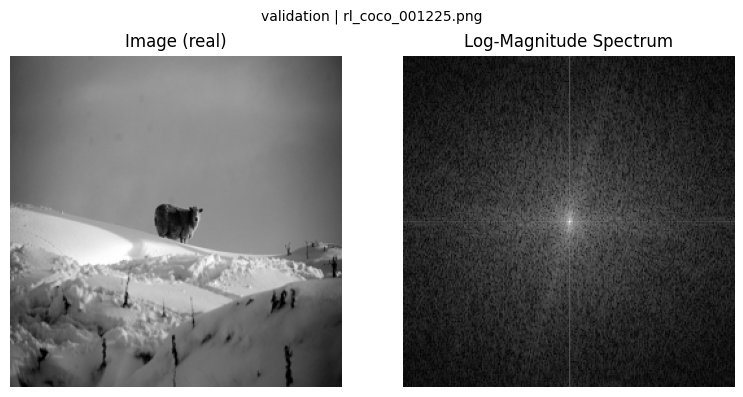


VALIDATION | Image 2 of 4
Filename: rl_imgn_000194.png
Label: real | Source: ImageNet_1K_256
Low Frequency Energy Ratio    : 0.985860
Mid Frequency Energy Ratio    : 0.012399
High Frequency Energy Ratio   : 0.001741
Radial Mean                   : 10114748.000000
Radial Std                    : 135129376.000000
Radial Entropy                : 0.049157
Spectral Centroid             : 0.025657
Spectral Bandwidth            : 0.576072
Log Spectrum Std              : 0.997020


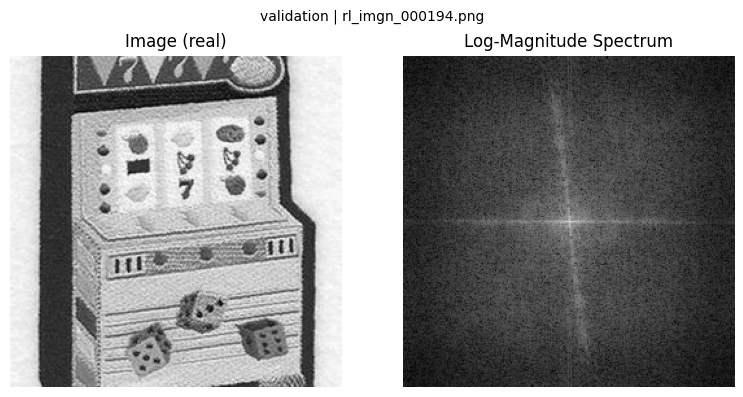


VALIDATION | Image 3 of 4
Filename: ai_diff_001688.png
Label: ai | Source: DiffusionDB
Low Frequency Energy Ratio    : 0.975237
Mid Frequency Energy Ratio    : 0.022435
High Frequency Energy Ratio   : 0.002328
Radial Mean                   : 4790400.000000
Radial Std                    : 62899188.000000
Radial Entropy                : 0.049157
Spectral Centroid             : 0.072499
Spectral Bandwidth            : 0.939356
Log Spectrum Std              : 1.157250


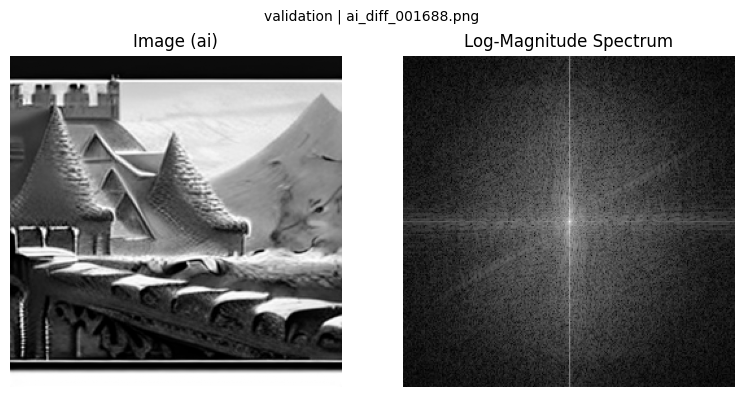


VALIDATION | Image 4 of 4
Filename: ai_sdxl_002194.png
Label: ai | Source: SDXL_Generated_10K
Low Frequency Energy Ratio    : 0.999461
Mid Frequency Energy Ratio    : 0.000441
High Frequency Energy Ratio   : 0.000098
Radial Mean                   : 7681252.500000
Radial Std                    : 103049872.000000
Radial Entropy                : 0.049157
Spectral Centroid             : 0.004178
Spectral Bandwidth            : 0.143185
Log Spectrum Std              : 0.788099


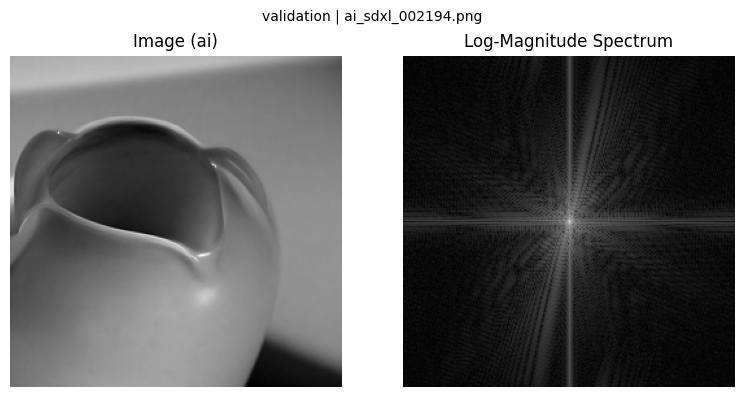

In [12]:
# ============================================
# Cell 10: Compare Real vs AI Images
# ============================================

# Select 2 real and 2 AI images (safe sampling)
df_real = df[df["class_label"] == "real"].sample(n=min(2, len(df[df["class_label"] == "real"])), random_state=42)
df_ai   = df[df["class_label"] == "ai"].sample(n=min(2, len(df[df["class_label"] == "ai"])), random_state=42)

sample_df = pd.concat([df_real, df_ai], axis=0).reset_index(drop=True)

print(f"Selected images from {SPLIT_NAME} split:")
print(sample_df[["filename", "class_label", "source_dataset"]].to_string(index=False))
print("\nClass counts:")
print(sample_df["class_label"].value_counts().to_string())
print("\nTotal selected:", len(sample_df))

for i, row in sample_df.iterrows():
    fname = row["filename"]
    label = row["class_label"]
    source = row["source_dataset"]

    image_path = os.path.join(IMG_DIR, fname)

    img_sample = load_preprocessed_image(image_path)
    features_sample, log_mag_s, power_s, radial_vals_s = extract_frequency_features(img_sample)

    print("\n============================================")
    print(f"{SPLIT_NAME.upper()} | Image {i+1} of {len(sample_df)}")
    print(f"Filename: {fname}")
    print(f"Label: {label} | Source: {source}")

    for k, v in features_sample.items():
        print(f"{k:30s}: {v:.6f}")

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_sample, cmap="gray")
    plt.title(f"Image ({label})")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(log_mag_s, cmap="gray")
    plt.title("Log-Magnitude Spectrum")
    plt.axis("off")

    plt.suptitle(f"{SPLIT_NAME} | {fname}", fontsize=10)
    plt.tight_layout()
    plt.show()


In [13]:
# ============================================
# Cell 11: Batch Frequency Feature Extraction
# ============================================

rows = []

for _, row in df.iterrows():
    fname = row["filename"]
    image_path = os.path.join(IMG_DIR, fname)

    try:
        img_batch = load_preprocessed_image(image_path)

        features_batch, _, _, _ = extract_frequency_features(img_batch)

        out_row = row.to_dict()
        out_row.update(features_batch)

        rows.append(out_row)

    except Exception as e:
        print(f"Skipping {fname}: {e}")

# Create DataFrame
features_df = pd.DataFrame(rows)

# Save to CSV
features_df.to_csv(OUTPUT_CSV, index=False)

print(f"Saved: {OUTPUT_CSV}")
print("Shape:", features_df.shape)
print(f"Processed split: {SPLIT_NAME}")



Saved: /content/validation_frequency_features.csv
Shape: (1800, 14)
Processed split: validation
